# Seasonal Agriculture Performance Analysis

**VOIS AICTE AUGUST BATCH (2026-2027) - Major Project, Data Analytics**

Name: [GEETIKA MAHOUR] | College: Saraswati College of engineering | AICTE STU ID: [STU6a2aedcc770751781198284]

---

## 1. Problem Statement

Agricultural performance changes with seasonal conditions, farming practices, resource availability and market conditions, but raw farm-level data does not show *how* performance differs from one season to another. This project analyses a dataset of 4,000 farms across the **Kharif, Rabi and Zaid** seasons to find meaningful patterns, relationships and differences in agricultural performance, and turns them into evidence-based recommendations for seasonal planning.

## 2. Objectives

1. Explore and understand the dataset.
2. Clean and prepare the data.
3. Compare agricultural performance (yield, economics) across seasons.
4. Compare resource usage and environmental conditions across seasons.
5. Test whether seasonal differences are statistically significant.
6. Investigate relationships between conditions and outcomes.
7. Check whether patterns are consistent across crops, states and irrigation methods.
8. Identify unusual patterns and draw data-driven recommendations.

## 3. Analytical Questions

- **Q1.** How do yield, profit and benefit-cost ratio differ between seasons?
- **Q2.** Do production costs, market prices and revenue differ by season?
- **Q3.** Does resource use (water, fertilizer, pesticide) differ by season?
- **Q4.** How do rainfall, temperature, humidity and pest risk differ by season?
- **Q5.** Which conditions are most strongly related to yield and profitability in each season?
- **Q6.** Does irrigation method matter more in some seasons than others?
- **Q7.** Are the seasonal patterns consistent across crops and states?
- **Q8.** Which farms behave unusually, and why?

## 4. Setup

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

SEASONS = ["Kharif", "Rabi", "Zaid"]
PALETTE = {"Kharif": "#2E7D32", "Rabi": "#F9A825", "Zaid": "#1565C0"}

os.makedirs("figures", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Load and Understand the Data

In [3]:
DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


**Column groups**

| Group | Columns |
|---|---|
| Identity / location | Farm_ID, State, District |
| Crop and season | Crop, Season, Farm_Area_Hectares |
| Environment | Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day |
| Soil | Soil_pH, Soil_Moisture_pct, Nitrogen/Phosphorus/Potassium_kg_ha |
| Farming practice | Irrigation_Method, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score |
| Output | Yield_Tonnes_Ha, Production_Tonnes |
| Economics | Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR |
| Water and risk | Water_Used_m3, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct |

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [6]:
for col in ["Season", "Crop", "State", "Irrigation_Method"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string(), "\n")

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594 

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305 

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484 

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734 



## 6. Data Quality Audit

In [7]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df.Farm_ID.duplicated().sum())
audit[audit.missing > 0]

Duplicate rows: 0
Duplicate Farm_IDs: 0


,dtype,missing,missing_pct,unique
Rainfall_mm,float64,48,1.20,3256
Soil_Moisture_pct,float64,40,1.00,343
Yield_Tonnes_Ha,float64,32,0.80,738


In [8]:
# Internal consistency checks
yield_check = (df.Production_Tonnes / df.Farm_Area_Hectares)
ok_yield = np.isclose(yield_check[df.Yield_Tonnes_Ha.notna()], df.Yield_Tonnes_Ha.dropna(), atol=0.02).mean()
ok_profit = ((df.Revenue_INR - df.Total_Cost_INR) == df.Profit_INR).mean()
print(f"Yield = Production / Area holds for {ok_yield:.1%} of rows with a yield value")
print(f"Profit = Revenue - Cost holds for {ok_profit:.1%} of rows")

# State-district consistency
states_per_district = df.groupby("District").State.nunique()
print("\nStates recorded per district (should be 1 in real geography):")
print(states_per_district.to_string())

Yield = Production / Area holds for 100.0% of rows with a yield value
Profit = Revenue - Cost holds for 100.0% of rows

States recorded per district (should be 1 in real geography):
District
Erode       8
Guntur      8
Indore      8
Krishna     8
Ludhiana    8
Nalgonda    8
Nashik      8
Raichur     8
Rajkot      8
Warangal    8


**Audit notes**

- Missing values are limited to `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`.
- Yield is exactly `Production / Area`, so missing yields can be recomputed instead of guessed.
- Every district appears under several states (for example Rajkot under Andhra Pradesh), so the State-District pairing is not geographically reliable. This project therefore uses **State** and **Crop** for grouping and does **not** draw district-level conclusions.

## 7. Data Cleaning

In [9]:
# 1) Recompute missing yield from production and area (verified identity)
missing_yield = df.Yield_Tonnes_Ha.isna()
df.loc[missing_yield, "Yield_Tonnes_Ha"] = (
    df.loc[missing_yield, "Production_Tonnes"] / df.loc[missing_yield, "Farm_Area_Hectares"]
)

# 2) Impute rainfall and soil moisture with the median of the same Crop and Season
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df[col + "_was_missing"] = df[col].isna()
    df[col] = df[col].fillna(df.groupby(["Crop", "Season"])[col].transform("median"))

print("Missing values after cleaning:", int(df[df_raw.columns].isna().sum().sum()))

Missing values after cleaning: 0


In [10]:
# 3) Range validation against plausible agronomic limits
checks = {
    "Soil_pH (4-9)": df.Soil_pH.between(4, 9),
    "Humidity_pct (0-100)": df.Humidity_pct.between(0, 100),
    "Disease_Pest_Risk_pct (0-100)": df.Disease_Pest_Risk_pct.between(0, 100),
    "Seed_Quality_Score (0-1)": df.Seed_Quality_Score.between(0, 1),
    "Farm_Area_Hectares > 0": df.Farm_Area_Hectares > 0,
    "Production_Tonnes > 0": df.Production_Tonnes > 0,
}
pd.Series({k: bool(v.all()) for k, v in checks.items()}, name="All rows valid")

,All rows valid
Soil_pH (4-9),True
Humidity_pct (0-100),True
Disease_Pest_Risk_pct (0-100),True
Seed_Quality_Score (0-1),True
Farm_Area_Hectares > 0,True
Production_Tonnes > 0,True


In [11]:
# 4) Outlier review (IQR rule on yield, per crop). Outliers are FLAGGED, not deleted,
# because they can be genuine high-performing farms.
def iqr_flags(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

df["Yield_Outlier"] = df.groupby("Crop").Yield_Tonnes_Ha.transform(lambda s: iqr_flags(s))
outlier_table = df.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Outliers=("Yield_Outlier", "sum"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Max_Yield=("Yield_Tonnes_Ha", "max"),
)
outlier_table

,Farms,Outliers,Median_Yield,Max_Yield
Crop,,,,
Chilli,412,0,1.56,3.90
Cotton,508,1,1.24,2.90
Groundnut,424,0,1.40,3.02
Maize,551,0,2.85,6.08
Pulses,496,0,0.94,2.09
Rice,690,0,2.46,5.70
Sugarcane,305,0,48.03,101.44
Wheat,614,0,2.21,4.56


**Why yield must be compared *within* crop.** Sugarcane yields tens of tonnes per hectare while pulses yield about one, so a raw seasonal average of yield mostly reflects *which crops were grown*, not the season. The next step builds crop-adjusted measures.

## 8. Feature Engineering

In [12]:
crop_median = lambda col: df.groupby("Crop")[col].transform("median")

# Crop-adjusted indices (1.0 = typical farm of that crop)
df["Yield_Index"] = df.Yield_Tonnes_Ha / crop_median("Yield_Tonnes_Ha")
df["Price_Index"] = df.Market_Price_INR_Tonne / crop_median("Market_Price_INR_Tonne")

# Per-hectare economics so farm size does not distort comparisons
df["Cost_per_ha"] = df.Total_Cost_INR / df.Farm_Area_Hectares
df["Revenue_per_ha"] = df.Revenue_INR / df.Farm_Area_Hectares
df["Profit_per_ha"] = df.Profit_INR / df.Farm_Area_Hectares

# Benefit-Cost Ratio: revenue earned per rupee spent (>1 means profitable)
df["BCR"] = df.Revenue_INR / df.Total_Cost_INR
df["Loss_Making"] = df.Profit_INR < 0

# Resource intensity
df["Water_per_ha"] = df.Water_Used_m3 / df.Farm_Area_Hectares
df["NPK_total"] = df.Nitrogen_kg_ha + df.Phosphorus_kg_ha + df.Potassium_kg_ha

df["Season"] = pd.Categorical(df.Season, categories=SEASONS, ordered=True)
df[["Season", "Crop", "Yield_Index", "Price_Index", "Profit_per_ha", "BCR", "Loss_Making", "Water_per_ha"]].head()

,Season,Crop,Yield_Index,Price_Index,Profit_per_ha,BCR,Loss_Making,Water_per_ha
0,Kharif,Wheat,1.11,0.99,"-22,362.26",0.72,True,447.17
1,Kharif,Maize,0.11,0.98,"-69,211.33",0.08,True,758.50
2,Rabi,Pulses,0.55,1.06,"-25,667.49",0.60,True,262.35
3,Kharif,Rice,0.75,1.10,"-21,267.56",0.68,True,852.00
4,Zaid,Maize,0.78,0.99,"-34,287.89",0.57,True,780.76


- **Yield_Index**: a farm's yield divided by the median yield of its crop. Values above 1 mean better than a typical farm of that crop.
- **Price_Index**: the same idea for market price.
- **BCR**: revenue divided by total cost. Unlike profit margin, it stays well-behaved when revenue is very low.
- **Per-hectare measures** remove the effect of farm size.

## 9. Seasonal Overview (Q1)

In [13]:
overview = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Median_Yield_Index=("Yield_Index", "median"),
    Median_Profit_per_ha=("Profit_per_ha", "median"),
    Median_BCR=("BCR", "median"),
    Loss_Making_Share=("Loss_Making", "mean"),
    Median_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "median"),
)
overview["Loss_Making_Share"] = overview["Loss_Making_Share"] * 100
overview.rename(columns={"Loss_Making_Share": "Loss_Making_%"})

,Farms,Median_Yield_Index,Median_Profit_per_ha,Median_BCR,Loss_Making_%,Median_Water_Efficiency
Season,,,,,,
Kharif,1779,1.13,"8,340.45",1.12,42.21,3.28
Rabi,1627,0.97,-894.33,0.99,51.14,2.74
Zaid,594,0.79,"-13,760.26",0.80,64.48,2.30


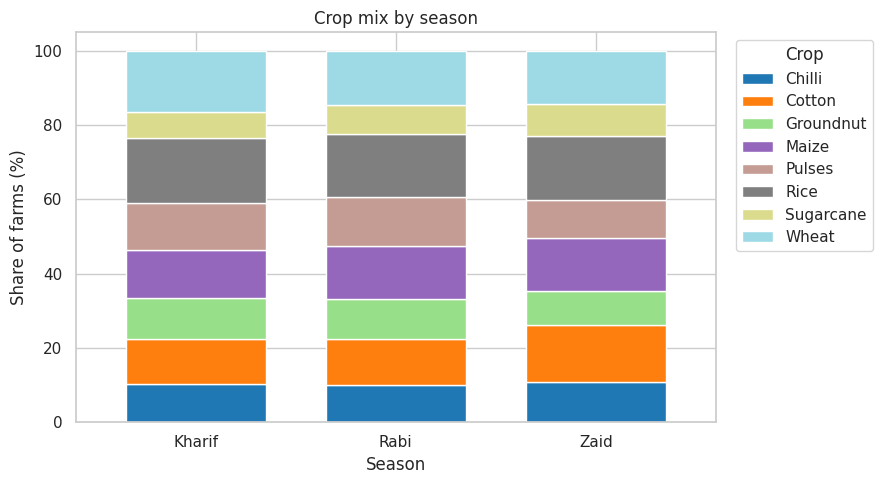

In [14]:
# Crop mix per season (are seasons growing comparable crops?)
mix = pd.crosstab(df.Season, df.Crop, normalize="index") * 100
ax = mix.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="tab20", width=0.7)
ax.set_ylabel("Share of farms (%)")
ax.set_title("Crop mix by season")
ax.legend(title="Crop", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
save("01_crop_mix_by_season")

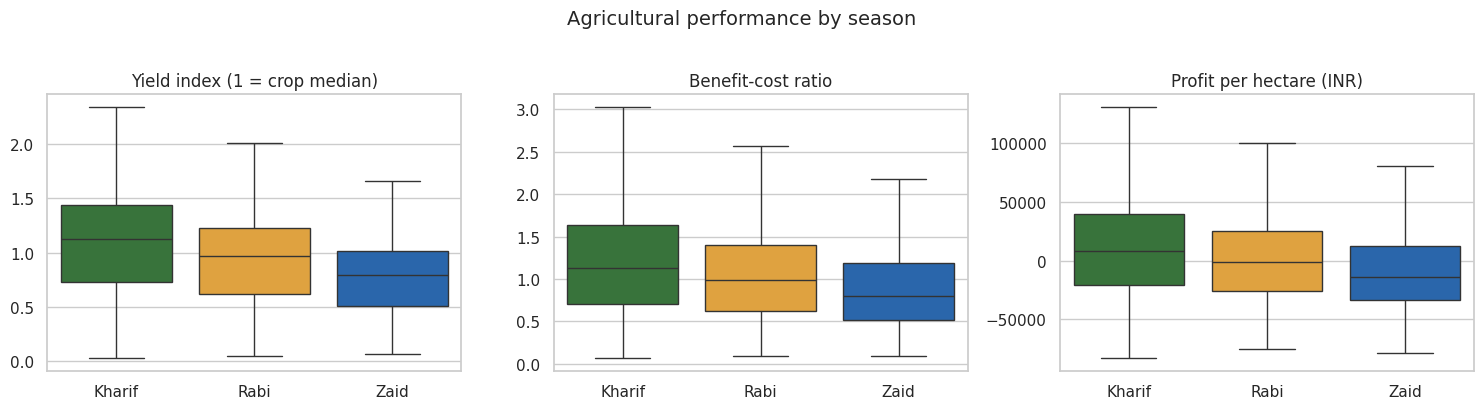

In [15]:
def box_panel(cols, titles, ncols, fname, suptitle, height=4):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, height * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col, title in zip(axes, cols, titles):
        sns.boxplot(data=df, x="Season", y=col, order=SEASONS, palette=PALETTE,
                    showfliers=False, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=14, y=1.02)
    save(fname)

box_panel(
    ["Yield_Index", "BCR", "Profit_per_ha"],
    ["Yield index (1 = crop median)", "Benefit-cost ratio", "Profit per hectare (INR)"],
    3, "02_performance_by_season", "Agricultural performance by season",
)

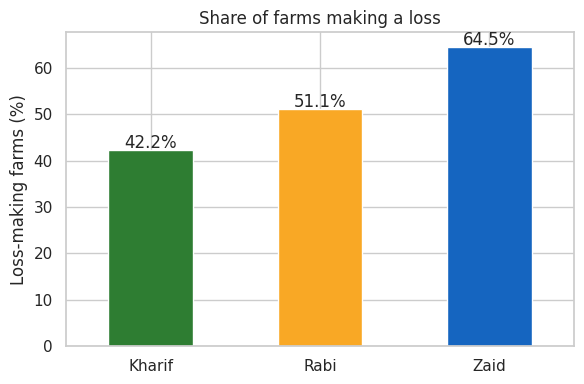

In [16]:
# Share of loss-making farms
loss = df.groupby("Season").Loss_Making.mean().mul(100).reindex(SEASONS)
ax = loss.plot(kind="bar", color=[PALETTE[s] for s in SEASONS], figsize=(6, 4))
for i, v in enumerate(loss):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set_ylabel("Loss-making farms (%)")
ax.set_xlabel("")
ax.set_title("Share of farms making a loss")
plt.xticks(rotation=0)
save("03_loss_share_by_season")

## 10. Economic Drivers (Q2)

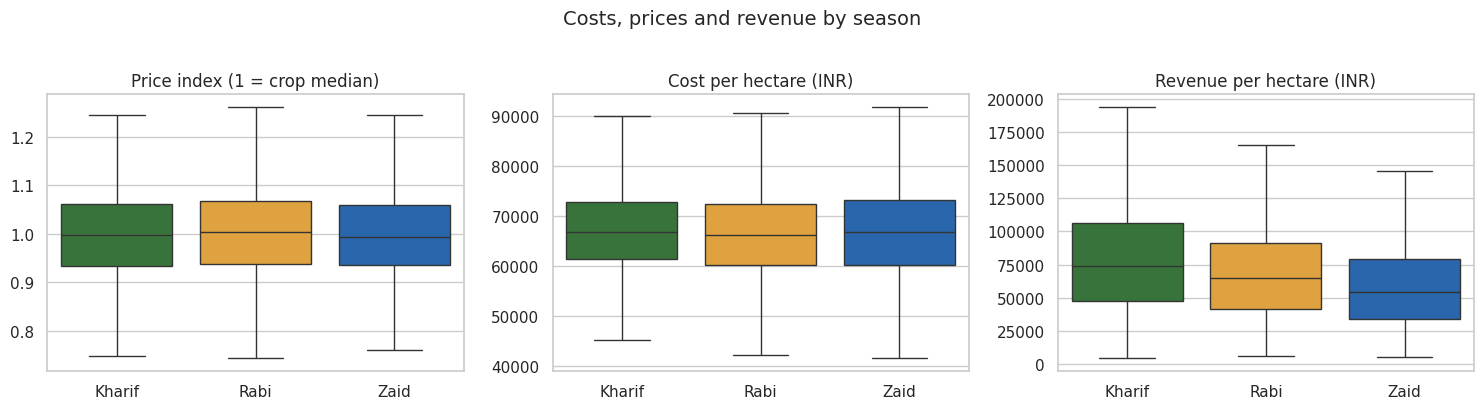

In [17]:
box_panel(
    ["Price_Index", "Cost_per_ha", "Revenue_per_ha"],
    ["Price index (1 = crop median)", "Cost per hectare (INR)", "Revenue per hectare (INR)"],
    3, "04_economics_by_season", "Costs, prices and revenue by season",
)

## 11. Resource Usage (Q3)

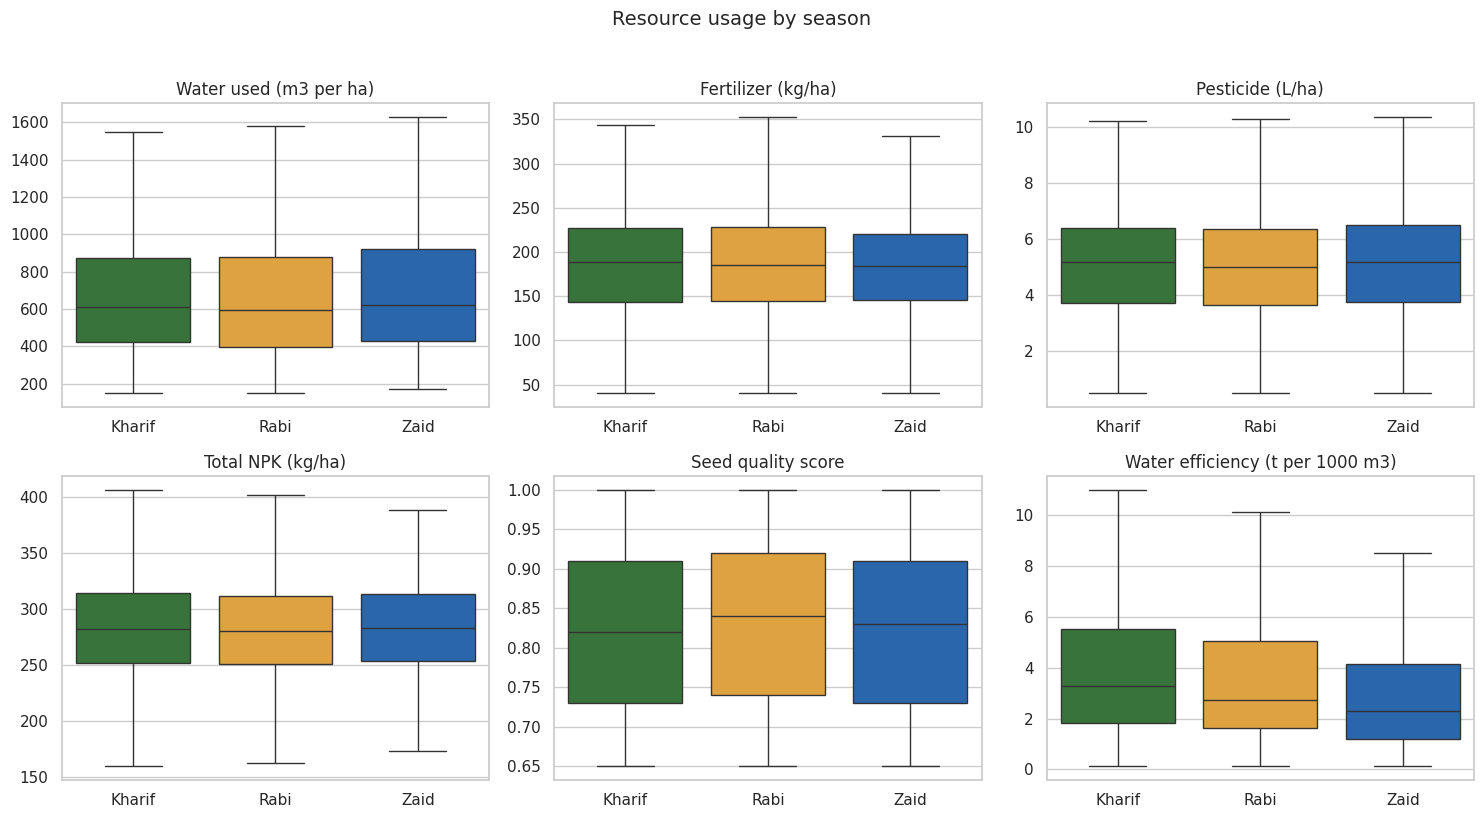

In [18]:
box_panel(
    ["Water_per_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
     "NPK_total", "Seed_Quality_Score", "Water_Efficiency_t_per_1000m3"],
    ["Water used (m3 per ha)", "Fertilizer (kg/ha)", "Pesticide (L/ha)",
     "Total NPK (kg/ha)", "Seed quality score", "Water efficiency (t per 1000 m3)"],
    3, "05_resource_use_by_season", "Resource usage by season",
)

## 12. Environmental Conditions and Risk (Q4)

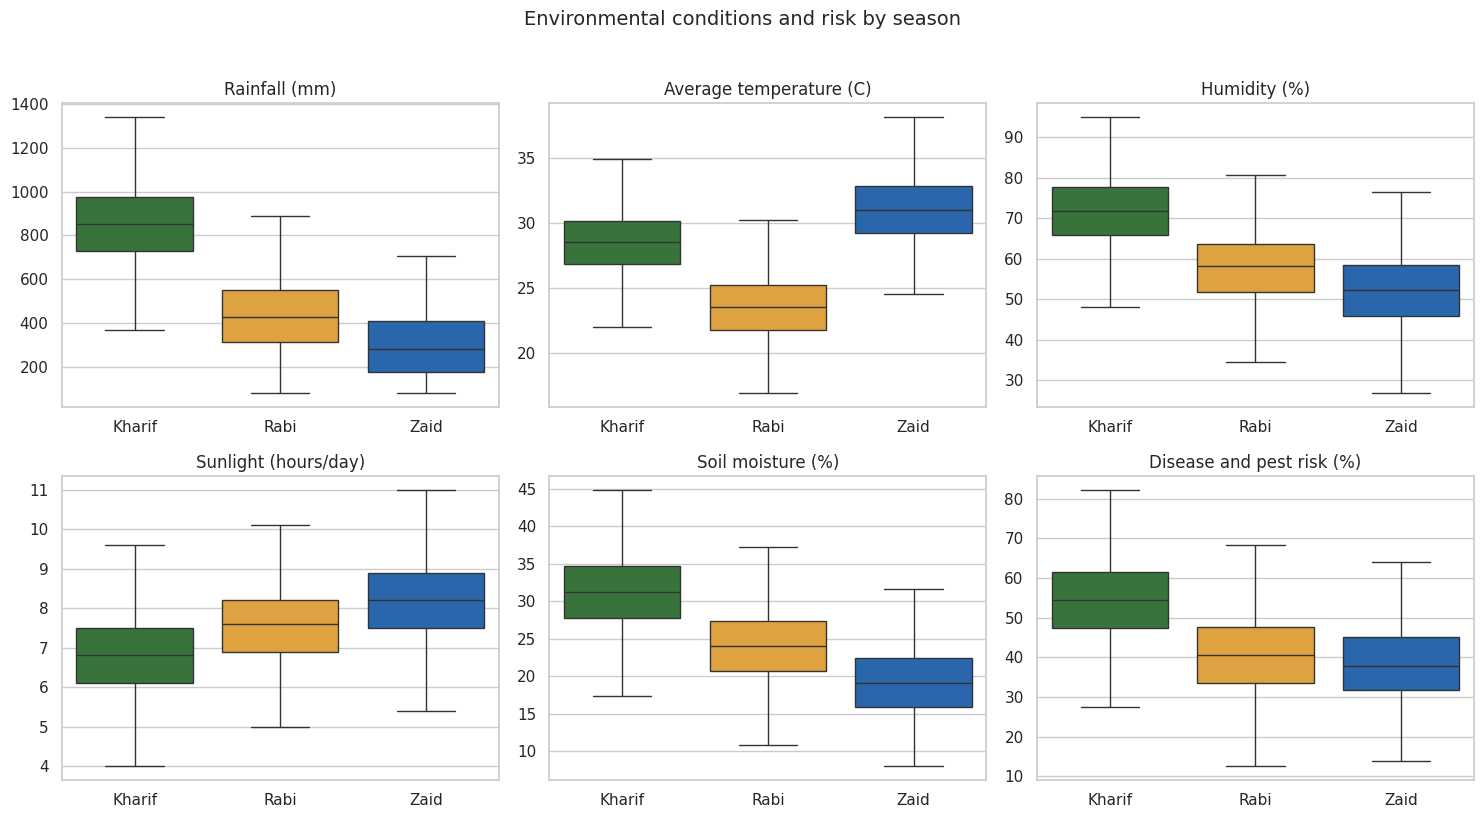

In [19]:
box_panel(
    ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
     "Sunlight_Hours_Day", "Soil_Moisture_pct", "Disease_Pest_Risk_pct"],
    ["Rainfall (mm)", "Average temperature (C)", "Humidity (%)",
     "Sunlight (hours/day)", "Soil moisture (%)", "Disease and pest risk (%)"],
    3, "06_environment_by_season", "Environmental conditions and risk by season",
)

In [20]:
median_table = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
    "Soil_Moisture_pct", "Disease_Pest_Risk_pct", "Water_per_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Cost_per_ha", "Price_Index",
]].median().T
median_table

Season,Kharif,Rabi,Zaid
Rainfall_mm,854.40,429.90,283.90
Avg_Temperature_C,28.50,23.50,31.00
Humidity_pct,71.90,58.10,52.35
Sunlight_Hours_Day,6.80,7.60,8.20
Soil_Moisture_pct,31.20,24.00,19.10
Disease_Pest_Risk_pct,54.50,40.60,37.90
Water_per_ha,610.15,595.45,619.05
Fertilizer_kg_ha,188.20,185.30,183.95
Pesticide_Litre_ha,5.18,5.02,5.19
Cost_per_ha,"66,741.30","66,281.40","66,743.20"


## 13. Are the Differences Statistically Significant?

Distributions here are skewed, so a **Kruskal-Wallis H test** (rank-based, no normality assumption) is used to compare the three seasons. Effect size is reported as epsilon-squared: about 0.01 is small, 0.06 medium and 0.14 large. For significant metrics, pairwise **Mann-Whitney U** tests with a Bonferroni correction show *which* seasons differ.

In [21]:
metrics = {
    "Yield_Index": "Yield index",
    "BCR": "Benefit-cost ratio",
    "Profit_per_ha": "Profit per ha",
    "Price_Index": "Price index",
    "Cost_per_ha": "Cost per ha",
    "Revenue_per_ha": "Revenue per ha",
    "Water_per_ha": "Water per ha",
    "Fertilizer_kg_ha": "Fertilizer",
    "Pesticide_Litre_ha": "Pesticide",
    "Water_Efficiency_t_per_1000m3": "Water efficiency",
    "Rainfall_mm": "Rainfall",
    "Avg_Temperature_C": "Temperature",
    "Humidity_pct": "Humidity",
    "Sunlight_Hours_Day": "Sunlight",
    "Soil_Moisture_pct": "Soil moisture",
    "Disease_Pest_Risk_pct": "Disease/pest risk",
}

rows = []
for col, label in metrics.items():
    groups = [df.loc[df.Season == s, col].dropna() for s in SEASONS]
    H, p = stats.kruskal(*groups)
    n, k = sum(len(g) for g in groups), len(groups)
    eps2 = max((H - k + 1) / (n - k), 0)
    rows.append({
        "Metric": label,
        "Kharif median": groups[0].median(),
        "Rabi median": groups[1].median(),
        "Zaid median": groups[2].median(),
        "H": H, "p-value": p, "Effect size": eps2,
        "Significant (p<0.05)": "Yes" if p < 0.05 else "No",
    })
kw = pd.DataFrame(rows).sort_values("Effect size", ascending=False).reset_index(drop=True)
kw.style.format({"p-value": "{:.2e}"}, precision=2)

,Metric,Kharif median,Rabi median,Zaid median,H,p-value,Effect size,Significant (p<0.05)
0,Rainfall,854.40,429.90,283.90,2599.88,0.00e+00,0.65,Yes
1,Temperature,28.50,23.50,31.00,2385.97,0.00e+00,0.60,Yes
2,Soil moisture,31.20,24.00,19.10,1857.61,0.00e+00,0.46,Yes
3,Humidity,71.90,58.10,52.35,1845.51,0.00e+00,0.46,Yes
4,Disease/pest risk,54.50,40.60,37.90,1430.91,1.91e-311,0.36,Yes
5,Sunlight,6.80,7.60,8.20,832.29,1.87e-181,0.21,Yes
6,Yield index,1.13,0.97,0.79,254.13,6.54e-56,0.06,Yes
7,Revenue per ha,74277.60,64980.14,54056.12,108.25,3.12e-24,0.03,Yes
8,Benefit-cost ratio,1.12,0.99,0.80,98.06,5.08e-22,0.02,Yes
9,Profit per ha,8340.45,-894.33,-13760.26,97.13,8.10e-22,0.02,Yes


In [22]:
# Post-hoc pairwise comparisons (Bonferroni: 3 comparisons per metric)
sig_metrics = [c for c, l in metrics.items() if l in kw.loc[kw["Significant (p<0.05)"] == "Yes", "Metric"].values]
post = []
for col in sig_metrics:
    for a, b in combinations(SEASONS, 2):
        x = df.loc[df.Season == a, col].dropna()
        y = df.loc[df.Season == b, col].dropna()
        _, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        post.append({"Metric": metrics[col], "Pair": f"{a} vs {b}",
                     "Median diff": x.median() - y.median(),
                     "Adj. p-value": min(p * 3, 1.0)})
post = pd.DataFrame(post)
post["Significant"] = np.where(post["Adj. p-value"] < 0.05, "Yes", "No")
post.style.format({"Adj. p-value": "{:.2e}"}, precision=2)

,Metric,Pair,Median diff,Adj. p-value,Significant
0,Yield index,Kharif vs Rabi,0.16,1.31e-22,Yes
1,Yield index,Kharif vs Zaid,0.34,1.29e-48,Yes
2,Yield index,Rabi vs Zaid,0.18,6.78e-18,Yes
3,Benefit-cost ratio,Kharif vs Rabi,0.14,5.09e-08,Yes
4,Benefit-cost ratio,Kharif vs Zaid,0.32,1.69e-20,Yes
5,Benefit-cost ratio,Rabi vs Zaid,0.18,2.05e-08,Yes
6,Profit per ha,Kharif vs Rabi,9234.78,5.32e-08,Yes
7,Profit per ha,Kharif vs Zaid,22100.71,3.24e-20,Yes
8,Profit per ha,Rabi vs Zaid,12865.93,2.21e-08,Yes
9,Revenue per ha,Kharif vs Rabi,9297.46,5.35e-10,Yes


In [23]:
# Is the share of loss-making farms different by season? (chi-square test of independence)
ct = pd.crosstab(df.Season, df.Loss_Making)
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(ct, "\n")
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p:.2e}")

Loss_Making  False  True 
Season                   
Kharif        1028    751
Rabi           795    832
Zaid           211    383 

Chi-square = 92.65, dof = 2, p = 7.62e-21


## 14. Relationships Between Conditions and Outcomes (Q5)

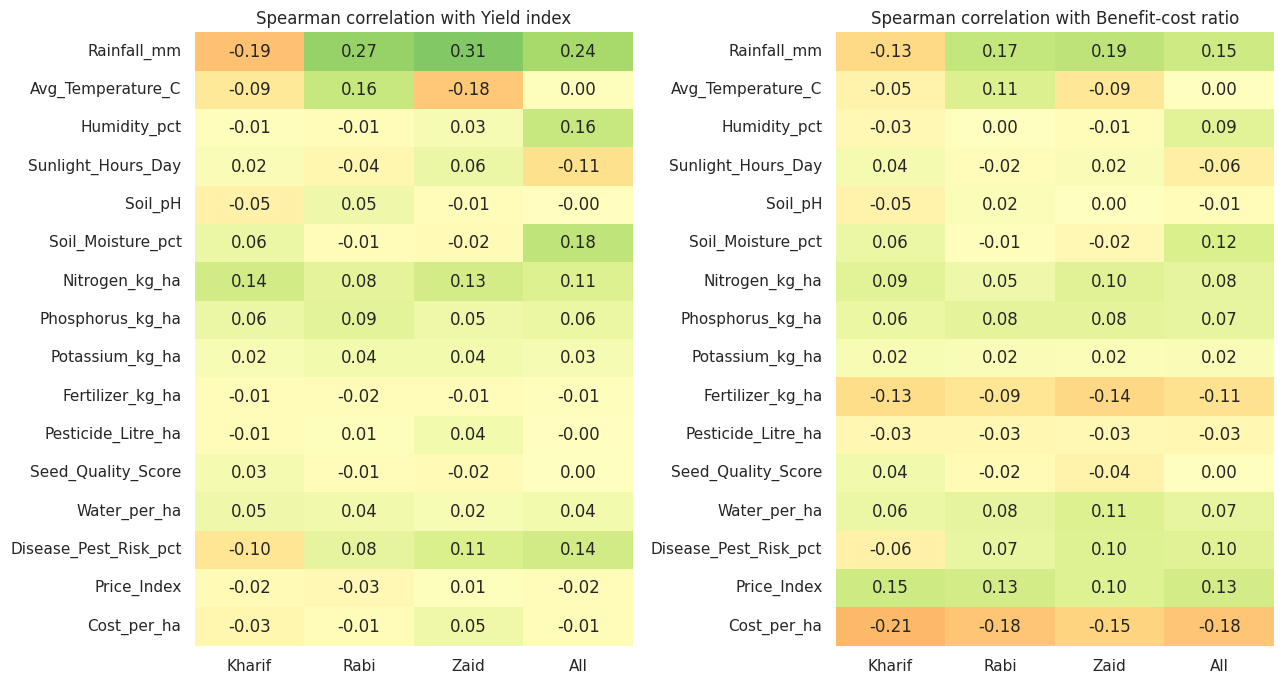

In [24]:
features = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
    "Soil_pH", "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Water_per_ha", "Disease_Pest_Risk_pct",
    "Price_Index", "Cost_per_ha",
]

def corr_by_season(target):
    out = {}
    for s in SEASONS:
        sub = df[df.Season == s]
        out[s] = sub[features].apply(lambda c: stats.spearmanr(c, sub[target])[0])
    out["All"] = df[features].apply(lambda c: stats.spearmanr(c, df[target])[0])
    return pd.DataFrame(out)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, target, title in zip(axes, ["Yield_Index", "BCR"], ["Yield index", "Benefit-cost ratio"]):
    sns.heatmap(corr_by_season(target), annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-0.6, vmax=0.6, cbar=False, ax=ax)
    ax.set_title(f"Spearman correlation with {title}")
save("07_correlation_by_season")

In [25]:
corr_yield = corr_by_season("Yield_Index")
corr_bcr = corr_by_season("BCR")
print("Strongest relationships with Yield_Index (all seasons):")
print(corr_yield["All"].reindex(corr_yield["All"].abs().sort_values(ascending=False).index).head(6).to_string())
print("\nStrongest relationships with BCR (all seasons):")
print(corr_bcr["All"].reindex(corr_bcr["All"].abs().sort_values(ascending=False).index).head(6).to_string())

Strongest relationships with Yield_Index (all seasons):
Rainfall_mm              0.24
Soil_Moisture_pct        0.18
Humidity_pct             0.16
Disease_Pest_Risk_pct    0.14
Sunlight_Hours_Day      -0.11
Nitrogen_kg_ha           0.11

Strongest relationships with BCR (all seasons):
Cost_per_ha             -0.18
Rainfall_mm              0.15
Price_Index              0.13
Soil_Moisture_pct        0.12
Fertilizer_kg_ha        -0.11
Disease_Pest_Risk_pct    0.10


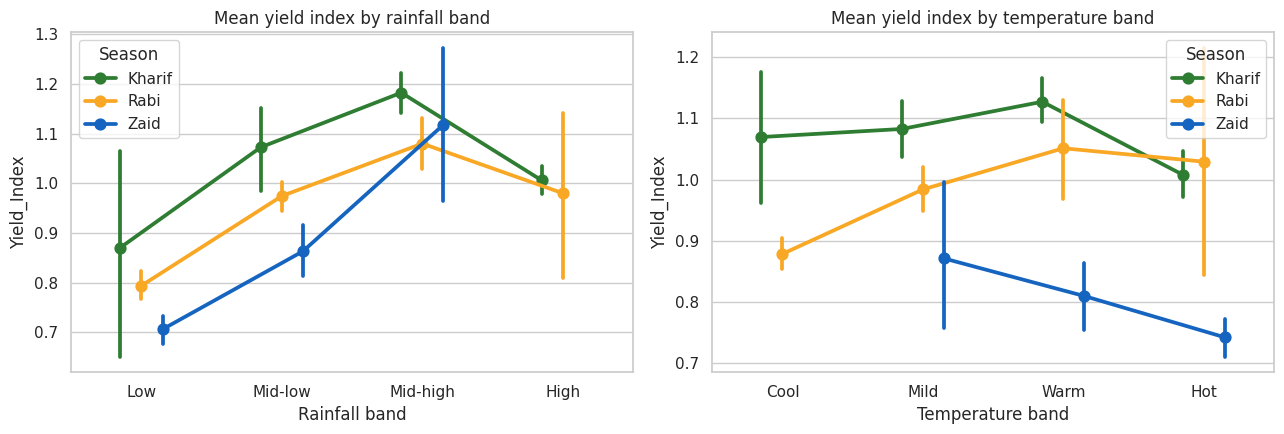

In [26]:
# Rainfall and temperature bands vs yield, separately for each season
df["Rain_Band"] = pd.qcut(df.Rainfall_mm, 4, labels=["Low", "Mid-low", "Mid-high", "High"])
df["Temp_Band"] = pd.qcut(df.Avg_Temperature_C, 4, labels=["Cool", "Mild", "Warm", "Hot"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, band, title in zip(axes, ["Rain_Band", "Temp_Band"], ["Rainfall band", "Temperature band"]):
    sns.pointplot(data=df, x=band, y="Yield_Index", hue="Season", hue_order=SEASONS,
                  palette=PALETTE, errorbar=("ci", 95), dodge=0.3, ax=ax)
    ax.set_title(f"Mean yield index by {title.lower()}")
    ax.set_xlabel(title)
save("08_yield_vs_rain_temp_bands")

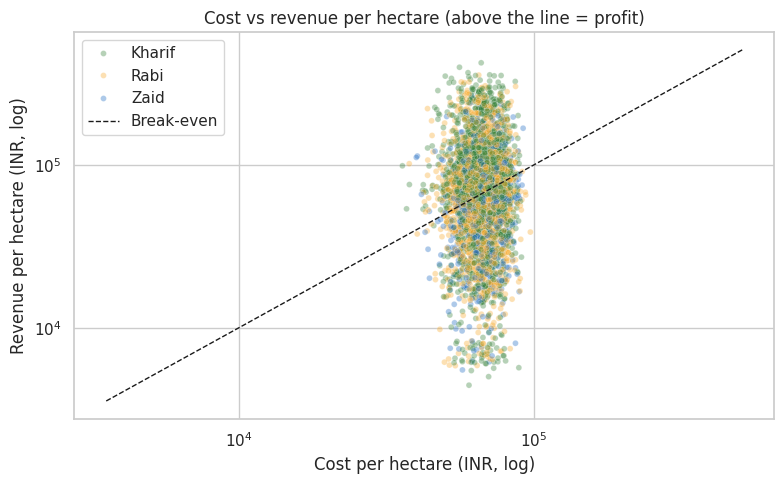

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Cost_per_ha", y="Revenue_per_ha", hue="Season",
                hue_order=SEASONS, palette=PALETTE, alpha=0.35, s=18, ax=ax)
lim = [df[["Cost_per_ha", "Revenue_per_ha"]].min().min() * 0.8, df[["Cost_per_ha", "Revenue_per_ha"]].max().max() * 1.2]
ax.plot(lim, lim, "k--", lw=1, label="Break-even")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Cost per hectare (INR, log)"); ax.set_ylabel("Revenue per hectare (INR, log)")
ax.set_title("Cost vs revenue per hectare (above the line = profit)")
ax.legend()
save("09_cost_vs_revenue")

## 15. Does Irrigation Method Matter by Season? (Q6)

In [28]:
irr = df.groupby(["Irrigation_Method", "Season"]).agg(
    Farms=("Farm_ID", "count"),
    Median_Yield_Index=("Yield_Index", "median"),
    Median_BCR=("BCR", "median"),
    Loss_Share=("Loss_Making", "mean"),
    Median_Water_per_ha=("Water_per_ha", "median"),
).reset_index()
irr["Loss_Share"] *= 100
irr

,Irrigation_Method,Season,Farms,Median_Yield_Index,Median_BCR,Loss_Share,Median_Water_per_ha
0,Drip,Kharif,405,1.29,1.28,34.07,526.15
1,Drip,Rabi,370,1.11,1.16,39.46,529.77
2,Drip,Zaid,140,0.86,0.87,60.00,536.73
3,Flood,Kharif,590,1.12,1.06,46.27,762.92
4,Flood,Rabi,526,0.96,0.94,55.13,766.43
5,Flood,Zaid,194,0.75,0.77,66.49,807.06
6,Rainfed,Kharif,463,1.07,1.10,44.28,333.04
7,Rainfed,Rabi,438,0.91,0.94,55.48,325.60
8,Rainfed,Zaid,140,0.77,0.73,75.00,327.02
9,Sprinkler,Kharif,321,1.12,1.11,42.06,585.11


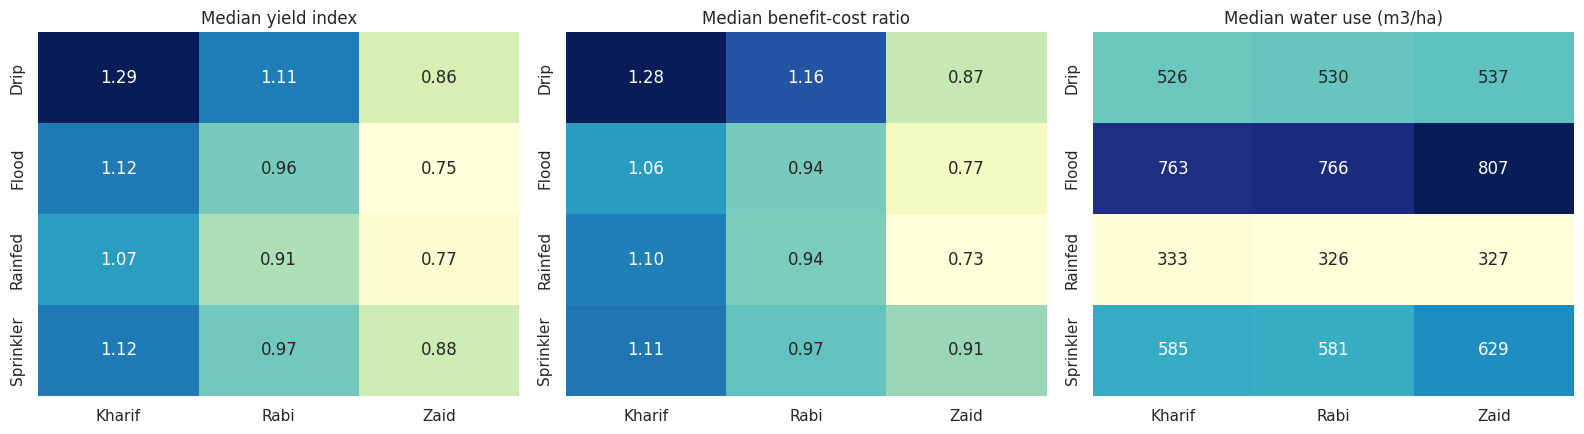

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(
    axes, ["Median_Yield_Index", "Median_BCR", "Median_Water_per_ha"],
    ["Median yield index", "Median benefit-cost ratio", "Median water use (m3/ha)"],
):
    pivot = irr.pivot(index="Irrigation_Method", columns="Season", values=col)[SEASONS]
    sns.heatmap(pivot, annot=True, fmt=".2f" if "Water" not in col else ".0f",
                cmap="YlGnBu", cbar=False, ax=ax)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
save("10_irrigation_by_season")

In [30]:
# Test irrigation effect on yield index inside each season
for s in SEASONS:
    groups = [g.Yield_Index.values for _, g in df[df.Season == s].groupby("Irrigation_Method")]
    H, p = stats.kruskal(*groups)
    print(f"{s}: irrigation effect on yield index  H = {H:.2f}, p = {p:.3g}")

Kharif: irrigation effect on yield index  H = 39.00, p = 1.74e-08
Rabi: irrigation effect on yield index  H = 44.74, p = 1.05e-09
Zaid: irrigation effect on yield index  H = 20.04, p = 0.000166


## 16. Are the Patterns Consistent Across Crops and States? (Q7)

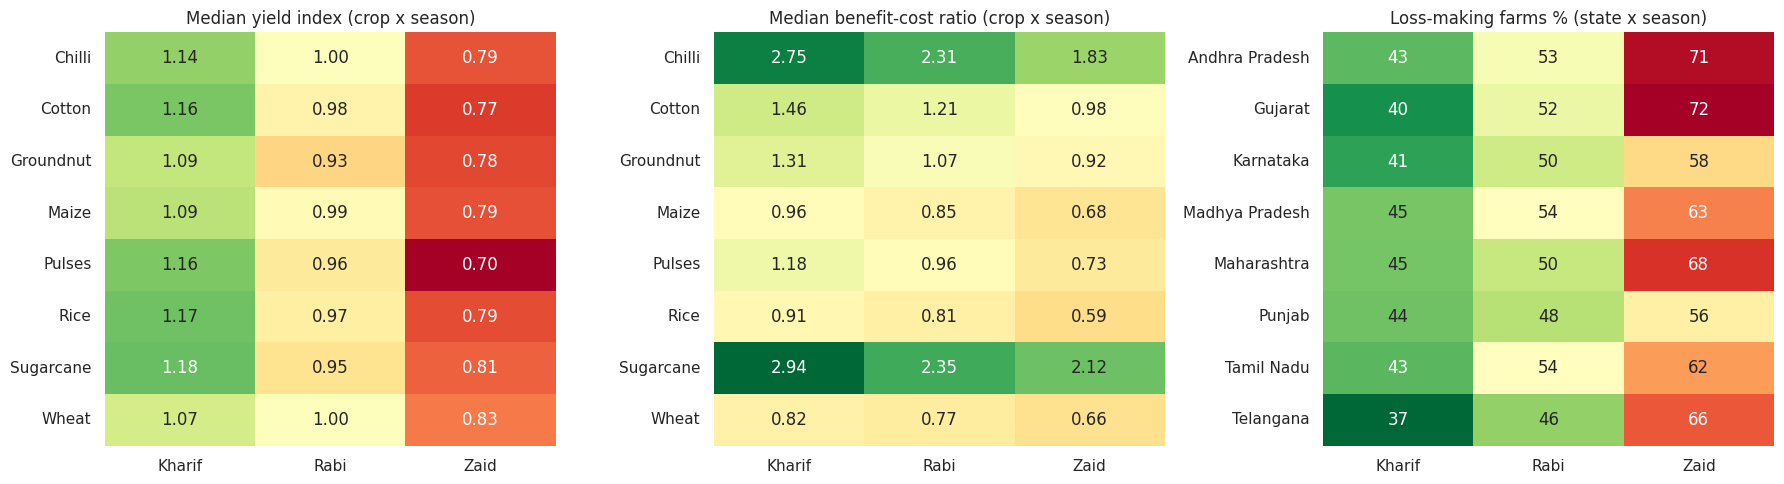

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

p1 = df.pivot_table(index="Crop", columns="Season", values="Yield_Index", aggfunc="median")[SEASONS]
sns.heatmap(p1, annot=True, fmt=".2f", cmap="RdYlGn", center=1, cbar=False, ax=axes[0])
axes[0].set_title("Median yield index (crop x season)")

p2 = df.pivot_table(index="Crop", columns="Season", values="BCR", aggfunc="median")[SEASONS]
sns.heatmap(p2, annot=True, fmt=".2f", cmap="RdYlGn", center=1, cbar=False, ax=axes[1])
axes[1].set_title("Median benefit-cost ratio (crop x season)")

p3 = df.pivot_table(index="State", columns="Season", values="Loss_Making", aggfunc="mean")[SEASONS] * 100
sns.heatmap(p3, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar=False, ax=axes[2])
axes[2].set_title("Loss-making farms % (state x season)")

for ax in axes:
    ax.set_xlabel(""); ax.set_ylabel("")
save("11_consistency_crop_state")

In [32]:
# How often does each season rank first / last?
def rank_counts(pivot, label):
    best = pivot.idxmax(axis=1).value_counts().reindex(SEASONS, fill_value=0)
    worst = pivot.idxmin(axis=1).value_counts().reindex(SEASONS, fill_value=0)
    return pd.DataFrame({f"{label}: best season": best, f"{label}: worst season": worst})

state_bcr = df.pivot_table(index="State", columns="Season", values="BCR", aggfunc="median")[SEASONS]
summary = pd.concat([
    rank_counts(p1, "Yield index, 8 crops"),
    rank_counts(p2, "BCR, 8 crops"),
    rank_counts(state_bcr, "BCR, 8 states"),
], axis=1)
summary

,"Yield index, 8 crops: best season","Yield index, 8 crops: worst season","BCR, 8 crops: best season","BCR, 8 crops: worst season","BCR, 8 states: best season","BCR, 8 states: worst season"
Kharif,8,0,8,0,8,0
Rabi,0,0,0,0,0,0
Zaid,0,8,0,8,0,8


## 17. Unusual Patterns (Q8)

In [33]:
# A) High-yield farms that still lose money
high_yield = df.Yield_Index >= df.Yield_Index.quantile(0.75)
hy_loss = df[high_yield & df.Loss_Making]
print(f"High-yield farms (top quartile): {high_yield.sum()}")
print(f"...of which loss-making: {len(hy_loss)} ({len(hy_loss) / high_yield.sum():.1%})\n")

compare = pd.DataFrame({
    "High-yield, profitable": df[high_yield & ~df.Loss_Making][["Price_Index", "Cost_per_ha", "Water_per_ha", "Fertilizer_kg_ha"]].median(),
    "High-yield, loss-making": hy_loss[["Price_Index", "Cost_per_ha", "Water_per_ha", "Fertilizer_kg_ha"]].median(),
})
print(compare.to_string())
print("\nSeason split of high-yield loss-makers (%):")
print((hy_loss.Season.value_counts(normalize=True).reindex(SEASONS) * 100).round(1).to_string())

High-yield farms (top quartile): 1001
...of which loss-making: 75 (7.5%)

                  High-yield, profitable  High-yield, loss-making
Price_Index                         1.00                     0.90
Cost_per_ha                    65,787.11                75,340.24
Water_per_ha                      613.34                   722.85
Fertilizer_kg_ha                  183.65                   217.00

Season split of high-yield loss-makers (%):
Season
Kharif   58.70
Rabi     37.30
Zaid      4.00


In [34]:
# B) Extreme profit per hectare within each crop (robust z-score with median and MAD)
def robust_z(s):
    mad = (s - s.median()).abs().median()
    return 0.6745 * (s - s.median()) / mad

df["Profit_Robust_Z"] = df.groupby("Crop").Profit_per_ha.transform(robust_z)
extreme = df[df.Profit_Robust_Z.abs() > 3.5]
print("Farms with extreme profit per hectare (|robust z| > 3.5):", len(extreme))
if len(extreme) == 0:
    print("No extreme profit outliers: profit per hectare varies widely but smoothly within each crop.")
else:
    print(extreme.Season.value_counts().reindex(SEASONS).to_string(), "\n")
    display(extreme.sort_values("Profit_Robust_Z", key=abs, ascending=False)[
        ["Farm_ID", "State", "Crop", "Season", "Yield_Index", "Price_Index", "Cost_per_ha", "Profit_per_ha"]
    ].head(10))

Farms with extreme profit per hectare (|robust z| > 3.5): 0
No extreme profit outliers: profit per hectare varies widely but smoothly within each crop.


In [35]:
# C) Farms using far more water than peers of the same crop
df["Water_Ratio"] = df.Water_per_ha / df.groupby("Crop").Water_per_ha.transform("median")
heavy = df[df.Water_Ratio > df.Water_Ratio.quantile(0.95)]
print("Top 5% water-intensive farms (relative to crop median):", len(heavy))
print(heavy.Season.value_counts(normalize=True).reindex(SEASONS).mul(100).round(1).to_string())
print("\nIrrigation mix among them (%):")
print(heavy.Irrigation_Method.value_counts(normalize=True).mul(100).round(1).to_string())

Top 5% water-intensive farms (relative to crop median): 200
Season
Kharif   43.00
Rabi     40.50
Zaid     16.50

Irrigation mix among them (%):
Irrigation_Method
Flood   100.00


## 18. Key Findings, Conclusions and Recommendations

### Key findings

1. **Performance falls steadily from Kharif to Rabi to Zaid.** Median yield index is 1.13 (Kharif), 0.97 (Rabi) and 0.79 (Zaid). Median benefit-cost ratio is 1.12, 0.99 and 0.80, and median profit per hectare is about +8,340, -894 and -13,760 INR. All three pairwise differences are significant after Bonferroni correction (Kruskal-Wallis p < 0.001 for yield, BCR and profit).
2. **Losses rise as the season gets drier and hotter.** 42% of Kharif farms lose money, versus 51% in Rabi and 64% in Zaid (chi-square p < 0.001).
3. **The ranking is perfectly consistent.** Kharif is best and Zaid is worst for yield index in all 8 crops, for BCR in all 8 crops, and for BCR in all 8 states. The seasonal effect is systematic, not driven by one crop or region.
4. **The gap comes from yield, not from inputs or prices.** Price index, cost per hectare, water use, fertilizer and pesticide use do **not** differ significantly between seasons (p > 0.05). Farms apply almost the same inputs in every season even though yield potential differs a lot, which points to a lack of seasonal input planning.
5. **Growing conditions differ sharply by season.** Median rainfall is 854 mm (Kharif), 430 mm (Rabi) and 284 mm (Zaid). Median temperature is 28.5, 23.5 and 31.0 C. Soil moisture and humidity follow rainfall. Disease and pest risk is highest in Kharif (54.5%) versus 40.6% (Rabi) and 37.9% (Zaid).
6. **Rainfall and temperature act differently in each season.** Across all farms, rainfall correlates positively with yield (rho = 0.24), but inside each season the sign changes: negative in Kharif (-0.19), positive in Rabi (+0.27) and Zaid (+0.31). Extra rain helps in the dry seasons but does not help, and may hurt, in the wet one. The all-farm correlation partly reflects the mix of seasons rather than a single effect.
7. **Drip irrigation leads in Kharif and Rabi and uses far less water than flood.** Median yield index under drip is 1.29 (Kharif) and 1.11 (Rabi), with the best BCR in both seasons (1.28 and 1.16). In Zaid sprinkler is slightly ahead (yield index 0.88 vs 0.86, BCR 0.91 vs 0.87) and every method stays below break-even. Drip uses about 30% less water than flood (about 530 vs 770 m3/ha). Rainfed farms have the lowest BCR in Zaid (0.73) and 75% of them lose money. Irrigation method changes yield significantly in every season (p < 0.001).
8. **Crop choice matters as much as season.** Chilli and sugarcane have the highest BCR in all three seasons (2.75 and 2.94 in Kharif, still 1.83 and 2.12 in Zaid). Rice, wheat and maize have median BCR below 1 in all seasons. In Zaid, only chilli and sugarcane stay above break-even at the median.
9. **Unusual pattern: high yield does not guarantee profit.** 75 of 1,001 high-yield farms (7.5%) still lost money. Compared with profitable high-yield farms they sold at lower prices (price index 0.90 vs 1.00) and spent more (cost per hectare about 75,300 vs 65,800 INR, water about 723 vs 613 m3/ha, fertilizer about 217 vs 184 kg/ha). All of the top 5% most water-intensive farms use flood irrigation.

### Conclusion

Seasonal conditions, mainly rainfall, temperature and moisture, drive a clear and consistent performance gradient: Kharif is the strongest season, Rabi is roughly break-even, and Zaid is mostly unprofitable. Because inputs and prices barely change between seasons, the difference in outcomes comes from what the season allows the crop to yield, and farms are not adjusting their practices to it.

### Recommendations

1. **Plan inputs season by season.** Since spending is nearly identical in all seasons while yield potential is not, cut fertilizer and water spend in Zaid, where returns rarely justify it, and reserve higher input levels for Kharif.
2. **Move away from flood and rainfed farming.** Drip gives the best yield and BCR in Kharif and Rabi (sprinkler is marginally ahead in Zaid) and uses about 30% less water than flood, which is the main driver of excess water use.
3. **Choose crops to match the season.** In Zaid, favor higher-value crops such as chilli and sugarcane where water is available. Review the economics of rice, wheat and maize, whose median BCR is below 1 in every season.
4. **Manage rainfall differently by season.** Invest in moisture conservation and supplementary irrigation in Rabi and Zaid, where more moisture lifts yield, and in drainage and pest monitoring in Kharif, where pest risk is highest and extra rain does not help.
5. **Protect margins on good yields.** Farms that grow well but lose money tend to overspend and sell below typical prices, so cost control and better market timing should accompany agronomic support.
6. **Next analysis.** With multi-year, farm-level records, model yield and profit directly (for example regression or gradient boosting) to quantify how much of the seasonal gap each condition explains.

## 19. Limitations

- The dataset looks synthetic or simulated: districts appear under multiple states, and every farm has a single season record, so this is a **cross-sectional** comparison, not a time series. Findings describe differences between groups of farms, not the same farm over time.
- Seasons are unbalanced (Zaid has far fewer farms), so Zaid estimates are less precise.
- Statistical significance does not prove causation; relationships shown are associations.
- Crop-adjusted indices assume the crop median is a fair benchmark for a "typical" farm.

## 20. Save the Cleaned Dataset

In [36]:
df.to_csv("cleaned_seasonal_agriculture.csv", index=False)
print("Saved cleaned_seasonal_agriculture.csv with shape", df.shape)

Saved cleaned_seasonal_agriculture.csv with shape (4000, 44)
